# 🎯 YOLOv8m — Multi-Object Apparel Detection & Instance Segmentation
**Visual Recognition Mini Project | Task 3.2**

- Model   : YOLOv8m-seg (Medium, instance segmentation)
- Dataset : DeepFashion2 — Top-5 clothing categories
- Two strategies: **Scratch** (random init) & **Transfer Learning** (COCO pretrained)
- Metrics : mAP@[0.5:0.95], mIoU, Dice, Per-class P/R/F1, ROC-AUC

In [1]:
# ── 0. Install dependencies ───────────────────────────────────────────────────
!pip install -q ultralytics scikit-learn matplotlib seaborn tqdm pycocotools

import os, json, shutil, random, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from pathlib import Path
from collections import Counter
from tqdm.auto import tqdm
from PIL import Image
warnings.filterwarnings('ignore')

from ultralytics import YOLO
import torch
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix
)

SEED = 42
random.seed(SEED); np.random.seed(SEED)

DEVICE = '0' if torch.cuda.is_available() else 'cpu'
print(f'Device : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU    : {torch.cuda.get_device_name(0)}')

# Output directory
OUT_DIR = Path('/kaggle/working')
OUT_DIR.mkdir(exist_ok=True)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 18.8 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Device : 0
GPU    : Tesla T4


In [2]:
# ── 1. Source paths ───────────────────────────────────────────────────────────
BASE      = Path('/kaggle/input/datasets/sudhirkh/deepfashion2/DeepFashion2')
TRAIN_IMG = BASE / 'train'      / 'image'
TRAIN_ANN = BASE / 'train'      / 'annos'
VAL_IMG   = BASE / 'validation' / 'image'
VAL_ANN   = BASE / 'validation' / 'annos'

print('Train images :', len(list(TRAIN_IMG.glob('*.jpg'))))
print('Val   images :', len(list(VAL_IMG.glob('*.jpg'))))

Train images : 191961
Val   images : 32153


In [3]:
# ── 2. Category setup ─────────────────────────────────────────────────────────
CAT_ID2NAME = {
    1:'short_sleeve_top', 2:'long_sleeve_top', 3:'short_sleeve_outwear',
    4:'long_sleeve_outwear', 5:'vest', 6:'sling', 7:'shorts',
    8:'trousers', 9:'skirt', 10:'short_sleeve_dress',
    11:'long_sleeve_dress', 12:'vest_dress', 13:'sling_dress'
}

# Find top-5 from training annotations
cat_counter = Counter()
for ann_file in tqdm(sorted(TRAIN_ANN.glob('*.json')), desc='Counting categories'):
    with open(ann_file) as f:
        ann = json.load(f)
    for v in ann.values():
        if isinstance(v, dict) and 'category_id' in v:
            cat_counter[v['category_id']] += 1

TOP5_IDS   = [cid for cid, _ in cat_counter.most_common(5)]
TOP5_NAMES = [CAT_ID2NAME[c] for c in TOP5_IDS]
CAT2YOLO   = {cid: i for i, cid in enumerate(TOP5_IDS)}   # map to 0-indexed YOLO class

print('Top-5 IDs  :', TOP5_IDS)
print('Top-5 Names:', TOP5_NAMES)
print('YOLO class map:', CAT2YOLO)

Counting categories:   0%|          | 0/191961 [00:00<?, ?it/s]

Top-5 IDs  : [1, 8, 7, 2, 9]
Top-5 Names: ['short_sleeve_top', 'trousers', 'shorts', 'long_sleeve_top', 'skirt']
YOLO class map: {1: 0, 8: 1, 7: 2, 2: 3, 9: 4}


In [4]:
# ── 3. Convert DeepFashion2 → YOLO segmentation format ───────────────────────
#
# YOLO segmentation label format (one line per instance):
#   <class_id> <x1> <y1> <x2> <y2> ... <xn> <yn>
# All coordinates normalised by image width/height (0.0 – 1.0)
#
YOLO_ROOT = OUT_DIR / 'deepfashion_yolo'

def convert_split(img_dir: Path, ann_dir: Path, split: str, max_samples=None):
    """
    Converts one split (train / val / test) to YOLO format.
    Returns list of image paths that had at least one top-5 instance.
    """
    img_out = YOLO_ROOT / split / 'images'
    lbl_out = YOLO_ROOT / split / 'labels'
    img_out.mkdir(parents=True, exist_ok=True)
    lbl_out.mkdir(parents=True, exist_ok=True)

    ann_files = sorted(ann_dir.glob('*.json'))
    if max_samples:
        ann_files = ann_files[:max_samples]

    kept = 0
    for ann_file in tqdm(ann_files, desc=f'Converting {split}'):
        img_src = img_dir / (ann_file.stem + '.jpg')
        if not img_src.exists():
            continue

        with open(ann_file) as f:
            ann = json.load(f)

        # Get image dimensions
        with Image.open(img_src) as im:
            W, H = im.size

        lines = []
        for v in ann.values():
            if not (isinstance(v, dict) and 'category_id' in v):
                continue
            cat_id = v['category_id']
            if cat_id not in TOP5_IDS:
                continue

            yolo_cls = CAT2YOLO[cat_id]
            segs     = v.get('segmentation', [])
            if not segs:
                # Fall back to bounding box if no polygon
                x1, y1, x2, y2 = v['bounding_box']
                segs = [[x1,y1, x2,y1, x2,y2, x1,y2]]

            for poly in segs:
                if len(poly) < 6:   # need at least 3 points
                    continue
                # Normalise
                coords = []
                for i in range(0, len(poly), 2):
                    x = max(0.0, min(1.0, poly[i]   / W))
                    y = max(0.0, min(1.0, poly[i+1] / H))
                    coords.extend([f'{x:.6f}', f'{y:.6f}'])
                lines.append(f'{yolo_cls} ' + ' '.join(coords))

        if not lines:
            continue

        # Copy image & write label
        shutil.copy(img_src, img_out / img_src.name)
        (lbl_out / (ann_file.stem + '.txt')).write_text('\n'.join(lines))
        kept += 1

    print(f'  {split}: {kept} images kept')
    return kept


# Convert — limit to 2000 train / 3000 val to stay within Kaggle disk limits
# Remove max_samples to use the full dataset (slower)
convert_split(TRAIN_IMG, TRAIN_ANN, 'train', max_samples=20000)
convert_split(VAL_IMG,   VAL_ANN,   'val',   max_samples=3000)

# Use val as test too (we'll evaluate on it)
print('Dataset conversion complete.')

Converting train:   0%|          | 0/20000 [00:00<?, ?it/s]

  train: 14949 images kept


Converting val:   0%|          | 0/3000 [00:00<?, ?it/s]

  val: 2002 images kept
Dataset conversion complete.


In [5]:
# ── 4. Write dataset.yaml ─────────────────────────────────────────────────────
yaml_content = f"""path: {YOLO_ROOT}
train: train/images
val:   val/images
test:  val/images

nc: {len(TOP5_IDS)}
names: {TOP5_NAMES}
"""

YAML_PATH = OUT_DIR / 'deepfashion.yaml'
YAML_PATH.write_text(yaml_content)
print('dataset.yaml written:')
print(yaml_content)

dataset.yaml written:
path: /kaggle/working/deepfashion_yolo
train: train/images
val:   val/images
test:  val/images

nc: 5
names: ['short_sleeve_top', 'trousers', 'shorts', 'long_sleeve_top', 'skirt']



In [6]:
print(yaml_content)

path: /kaggle/working/deepfashion_yolo
train: train/images
val:   val/images
test:  val/images

nc: 5
names: ['short_sleeve_top', 'trousers', 'shorts', 'long_sleeve_top', 'skirt']



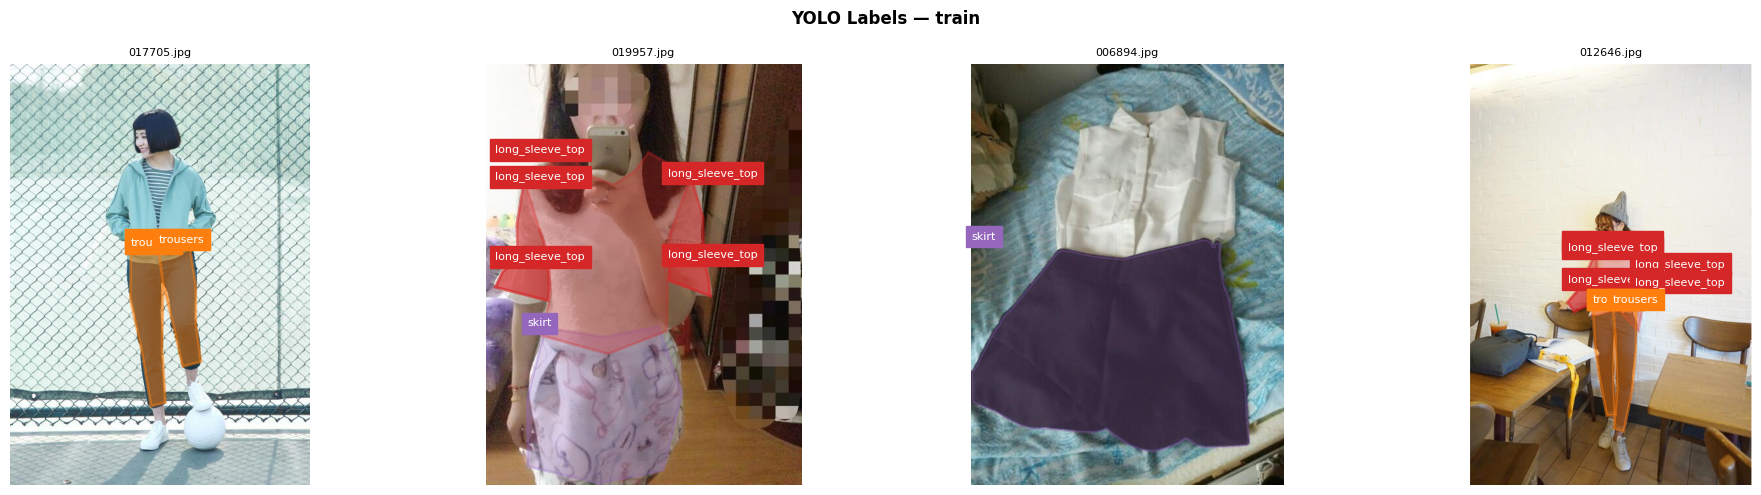

In [7]:
# ── 5. Verify dataset — visualise a few samples ───────────────────────────────
import matplotlib.patches as mpatches
from matplotlib.colors import to_rgba

COLORS = plt.cm.tab10.colors

def show_yolo_labels(split='train', n=4):
    img_dir = YOLO_ROOT / split / 'images'
    lbl_dir = YOLO_ROOT / split / 'labels'
    imgs    = random.sample(list(img_dir.glob('*.jpg')), min(n, len(list(img_dir.glob('*.jpg')))))

    fig, axes = plt.subplots(1, len(imgs), figsize=(5*len(imgs), 5))
    if len(imgs) == 1: axes = [axes]

    for ax, img_path in zip(axes, imgs):
        img = Image.open(img_path)
        W, H = img.size
        ax.imshow(img); ax.axis('off')

        lbl_path = lbl_dir / (img_path.stem + '.txt')
        if lbl_path.exists():
            for line in lbl_path.read_text().strip().split('\n'):
                parts = list(map(float, line.split()))
                cls   = int(parts[0])
                pts   = np.array(parts[1:]).reshape(-1, 2)
                pts[:, 0] *= W; pts[:, 1] *= H
                poly = plt.Polygon(pts, fill=True, alpha=0.3,
                                   color=COLORS[cls % 10], linewidth=2)
                ax.add_patch(poly)
                ax.text(pts[:,0].min(), pts[:,1].min(),
                        TOP5_NAMES[cls], fontsize=8,
                        color='white', backgroundcolor=COLORS[cls % 10])
        ax.set_title(img_path.name, fontsize=8)

    plt.suptitle(f'YOLO Labels — {split}', fontweight='bold')
    plt.tight_layout()
    plt.savefig(OUT_DIR / f'sample_{split}.png', dpi=150)
    plt.show()

show_yolo_labels('train', n=4)

In [8]:
# ── 7. Strategy B — Transfer Learning (COCO pretrained) ──────────────────────

print('=' * 60)
print('STRATEGY B : YOLOv8m-seg Transfer Learning (COCO)')
print('=' * 60)

model_tl = YOLO('yolov8m-seg.pt')

results_tl = model_tl.train(
    data     = str(YAML_PATH),
    epochs   = 30,
    imgsz    = 640,
    batch    = 8,
    device   = DEVICE,

    # 🔥 keep logs visible
    verbose  = True,

    # 🔥 stability tweaks (important for you)
    workers  = 2,
    cache    = False,   # you can switch to False if RAM issues

    project  = str(OUT_DIR / 'runs'),
    name     = 'transfer',

    pretrained = True,
    optimizer  = 'AdamW',
    lr0        = 1e-4,
    lrf        = 0.01,
    momentum   = 0.937,
    weight_decay = 0.0005,
    warmup_epochs = 1,

    freeze     = 10,

    augment    = True,
    mosaic     = 1.0,
    flipud     = 0.0,
    fliplr     = 0.5,
    degrees    = 10.0,
    translate  = 0.1,
    scale      = 0.5,

    patience   = 15,
    save       = True,
    plots      = True,
    seed       = SEED,
)

print('\nTransfer learning complete.')

TL_WEIGHTS = OUT_DIR / 'runs' / 'transfer' / 'weights' / 'best.pt'
print(f'Best weights: {TL_WEIGHTS}')

STRATEGY B : YOLOv8m-seg Transfer Learning (COCO)
Ultralytics 8.4.32 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/deepfashion.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=transfer, nbs=64, nms=False, opset=None, optimize=False, opti

In [9]:
model_tl

YOLO(
  (model): SegmentationModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 48, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(48, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(48, 96, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(96, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C2f(
        (cv1): Conv(
          (conv): Conv2d(96, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(96, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(192, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(96, eps=0.001, momentum=0.03, affine=True, track_runni

In [10]:
# # ── 8. Validation metrics (built-in YOLO) ─────────────────────────────────────
# print('\n--- Scratch Validation ---')
# m_scratch = YOLO(str(SCRATCH_WEIGHTS))
# val_scratch = m_scratch.val(data=str(YAML_PATH), imgsz=640, batch=8, device=DEVICE, verbose=True)

print('\n--- Transfer Validation ---')
m_tl = YOLO(str(TL_WEIGHTS))
val_tl = m_tl.val(data=str(YAML_PATH), imgsz=640, batch=8, device=DEVICE, verbose=True)


--- Transfer Validation ---
Ultralytics 8.4.32 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8m-seg summary (fused): 106 layers, 27,225,279 parameters, 0 gradients, 104.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 726.5±236.2 MB/s, size: 24.6 KB)
val: Scanning /kaggle/working/deepfashion_yolo/val/labels.cache... 2002 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2002/2002 763.4Mit/s 0.0s
val: /kaggle/working/deepfashion_yolo/val/images/000643.jpg: 1 duplicate labels removed
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 251/251 4.3it/s 58.7s
                   all       2002       3060      0.656      0.558      0.662      0.572      0.442      0.402      0.427      0.271
      short_sleeve_top        877        915      0.613      0.701      0.746      0.699      0.517       0.74      0.747      0.466
              trousers        520    

In [11]:
# ── 9. Extract & print all required metrics ───────────────────────────────────
def print_metrics(val_results, name):
    print(f'\n{"="*55}')
    print(f'  {name}')
    print(f'{"="*55}')

    # Detection metrics
    box = val_results.box
    print('\n  📦 DETECTION (Bounding Box):')
    print(f'    mAP@0.5          : {box.map50:.4f}')
    print(f'    mAP@[0.5:0.95]   : {box.map:.4f}')
    print(f'    Mean Precision   : {box.mp:.4f}')
    print(f'    Mean Recall      : {box.mr:.4f}')

    print('\n    Per-class Detection:')
    print(f'    {"Class":<28} {"AP50":>6} {"AP":>6}')
    print('    ' + '-'*44)
    for i, name_cls in enumerate(TOP5_NAMES):
        try:
            ap50 = float(box.ap50[i]) if hasattr(box, 'ap50') else float(box.ap[i])
            ap   = float(box.ap[i])
            print(f'    {name_cls:<28} {ap50:>6.4f} {ap:>6.4f}')
        except: pass

    # Segmentation metrics
    seg = val_results.seg
    print('\n  🎭 SEGMENTATION (Mask):')
    print(f'    mAP@0.5 (seg)    : {seg.map50:.4f}')
    print(f'    mAP@[0.5:0.95]   : {seg.map:.4f}')
    print(f'    Mean Precision   : {seg.mp:.4f}')
    print(f'    Mean Recall      : {seg.mr:.4f}')

    print('\n    Per-class Segmentation:')
    print(f'    {"Class":<28} {"AP50":>6} {"AP":>6}')
    print('    ' + '-'*44)
    for i, name_cls in enumerate(TOP5_NAMES):
        try:
            ap50 = float(seg.ap50[i]) if hasattr(seg, 'ap50') else float(seg.ap[i])
            ap   = float(seg.ap[i])
            print(f'    {name_cls:<28} {ap50:>6.4f} {ap:>6.4f}')
        except: pass

# print_metrics(val_scratch, 'SCRATCH')
print_metrics(val_tl,      'TRANSFER LEARNING')


  TRANSFER LEARNING

  📦 DETECTION (Bounding Box):
    mAP@0.5          : 0.6616
    mAP@[0.5:0.95]   : 0.5719
    Mean Precision   : 0.6557
    Mean Recall      : 0.5575

    Per-class Detection:
    Class                          AP50     AP
    --------------------------------------------
    short_sleeve_top             0.7465 0.6994
    trousers                     0.6009 0.4823
    shorts                       0.5456 0.4382
    long_sleeve_top              0.5699 0.4981
    skirt                        0.8449 0.7415

  🎭 SEGMENTATION (Mask):
    mAP@0.5 (seg)    : 0.4271
    mAP@[0.5:0.95]   : 0.2706
    Mean Precision   : 0.4415
    Mean Recall      : 0.4024

    Per-class Segmentation:
    Class                          AP50     AP
    --------------------------------------------
    short_sleeve_top             0.7474 0.4661
    trousers                     0.0289 0.0069
    shorts                       0.0453 0.0084
    long_sleeve_top              0.5178 0.2106
    skirt   

In [12]:
# ── 10. Compute mIoU & Dice from predictions ──────────────────────────────────
# Run inference on val set and compute mask-level IoU and Dice per class

def compute_miou_dice(model, img_dir: Path, lbl_dir: Path, imgsz=640, max_images=200):
    """
    Runs inference on up to max_images from img_dir,
    compares predicted masks vs ground-truth polygons,
    and returns per-class IoU and Dice.
    """
    img_paths = sorted(img_dir.glob('*.jpg'))[:max_images]

    iou_per_class  = {i: [] for i in range(len(TOP5_IDS))}
    dice_per_class = {i: [] for i in range(len(TOP5_IDS))}

    for img_path in tqdm(img_paths, desc='  Computing mIoU/Dice'):
        lbl_path = lbl_dir / (img_path.stem + '.txt')
        if not lbl_path.exists():
            continue

        with Image.open(img_path) as im:
            W, H = im.size

        # Ground truth masks (rasterise polygons)
        gt_masks = {i: np.zeros((H, W), dtype=np.uint8) for i in range(len(TOP5_IDS))}
        for line in lbl_path.read_text().strip().split('\n'):
            if not line.strip(): continue
            parts = list(map(float, line.split()))
            cls   = int(parts[0])
            pts   = np.array(parts[1:]).reshape(-1, 2)
            pts[:, 0] *= W; pts[:, 1] *= H
            from PIL import ImageDraw
            mask_img = Image.fromarray(gt_masks[cls])
            draw     = ImageDraw.Draw(mask_img)
            draw.polygon([tuple(p) for p in pts.tolist()], fill=1)
            gt_masks[cls] = np.array(mask_img)

        # Inference
        results = model.predict(str(img_path), imgsz=imgsz, conf=0.25, verbose=False)
        result  = results[0]

        pred_masks = {i: np.zeros((H, W), dtype=np.uint8) for i in range(len(TOP5_IDS))}
        if result.masks is not None:
            for mask_data, cls_id in zip(result.masks.data, result.boxes.cls):
                cls = int(cls_id.item())
                if cls >= len(TOP5_IDS): continue
                m = mask_data.cpu().numpy()
                m_resized = np.array(Image.fromarray((m * 255).astype(np.uint8)).resize((W, H))) > 127
                pred_masks[cls] = np.clip(pred_masks[cls] + m_resized.astype(np.uint8), 0, 1)

        # Compute IoU & Dice per class
        for cls in range(len(TOP5_IDS)):
            gt   = gt_masks[cls].astype(bool)
            pred = pred_masks[cls].astype(bool)
            if not gt.any() and not pred.any():
                continue
            inter = (gt & pred).sum()
            union = (gt | pred).sum()
            iou   = inter / (union + 1e-6)
            dice  = 2 * inter / (gt.sum() + pred.sum() + 1e-6)
            iou_per_class[cls].append(iou)
            dice_per_class[cls].append(dice)

    # Summarise
    print(f'\n  {"Class":<28} {"mIoU":>6} {"Dice":>6}')
    print('  ' + '-'*44)
    all_iou, all_dice = [], []
    for i, name in enumerate(TOP5_NAMES):
        iou_mean  = np.mean(iou_per_class[i])  if iou_per_class[i]  else 0.0
        dice_mean = np.mean(dice_per_class[i]) if dice_per_class[i] else 0.0
        all_iou.append(iou_mean); all_dice.append(dice_mean)
        print(f'  {name:<28} {iou_mean:>6.4f} {dice_mean:>6.4f}')
    print('  ' + '-'*44)
    print(f'  {"Macro avg":<28} {np.mean(all_iou):>6.4f} {np.mean(all_dice):>6.4f}')
    return all_iou, all_dice


val_img_dir = YOLO_ROOT / 'val' / 'images'
val_lbl_dir = YOLO_ROOT / 'val' / 'labels'

# print('\n🔵 mIoU & Dice — Scratch:')
# iou_s, dice_s = compute_miou_dice(m_scratch, val_img_dir, val_lbl_dir)

print('\n🟢 mIoU & Dice — Transfer Learning:')
iou_tl, dice_tl = compute_miou_dice(m_tl, val_img_dir, val_lbl_dir)


🟢 mIoU & Dice — Transfer Learning:


  Computing mIoU/Dice:   0%|          | 0/200 [00:00<?, ?it/s]


  Class                          mIoU   Dice
  --------------------------------------------
  short_sleeve_top             0.5882 0.6334
  trousers                     0.5570 0.6206
  shorts                       0.2151 0.2346
  long_sleeve_top              0.3675 0.3984
  skirt                        0.5850 0.6219
  --------------------------------------------
  Macro avg                    0.4626 0.5018


In [13]:
# ── 11. Per-class Precision / Recall / F1 & ROC-AUC ──────────────────────────
def compute_classification_metrics(model, img_dir, lbl_dir, max_images=200, conf=0.25):
    """
    Treats each image as a multi-label classification problem
    (which classes are detected vs which are present in GT)
    to compute P/R/F1 and ROC-AUC.
    """
    img_paths = sorted(img_dir.glob('*.jpg'))[:max_images]
    NC = len(TOP5_IDS)

    gt_labels   = []
    pred_probs  = []
    pred_labels = []

    for img_path in tqdm(img_paths, desc='  Class metrics'):
        lbl_path = lbl_dir / (img_path.stem + '.txt')
        if not lbl_path.exists(): continue

        # GT
        gt = np.zeros(NC)
        for line in lbl_path.read_text().strip().split('\n'):
            if line.strip(): gt[int(line.split()[0])] = 1

        # Predictions
        results = model.predict(str(img_path), conf=conf, verbose=False)
        result  = results[0]
        prob = np.zeros(NC)
        if result.boxes is not None and len(result.boxes):
            for box in result.boxes:
                cls = int(box.cls.item())
                if cls < NC:
                    prob[cls] = max(prob[cls], float(box.conf.item()))

        gt_labels.append(gt)
        pred_probs.append(prob)
        pred_labels.append((prob >= conf).astype(int))

    gt_labels   = np.array(gt_labels)
    pred_probs  = np.array(pred_probs)
    pred_labels = np.array(pred_labels)

    print(f'\n  {"Class":<28} {"P":>5} {"R":>5} {"F1":>5} {"AUC":>6}')
    print('  ' + '-'*52)
    aucs = []
    for i, name in enumerate(TOP5_NAMES):
        p  = precision_score(gt_labels[:,i], pred_labels[:,i], zero_division=0)
        r  = recall_score   (gt_labels[:,i], pred_labels[:,i], zero_division=0)
        f1 = f1_score       (gt_labels[:,i], pred_labels[:,i], zero_division=0)
        try:    auc = roc_auc_score(gt_labels[:,i], pred_probs[:,i])
        except: auc = float('nan')
        aucs.append(auc)
        print(f'  {name:<28} {p:>5.3f} {r:>5.3f} {f1:>5.3f} {auc:>6.4f}')
    print('  ' + '-'*52)
    mac_p  = precision_score(gt_labels, pred_labels, average='macro',  zero_division=0)
    mac_r  = recall_score   (gt_labels, pred_labels, average='macro',  zero_division=0)
    mac_f1 = f1_score       (gt_labels, pred_labels, average='macro',  zero_division=0)
    mic_f1 = f1_score       (gt_labels, pred_labels, average='micro',  zero_division=0)
    print(f'  {"Macro avg":<28} {mac_p:>5.3f} {mac_r:>5.3f} {mac_f1:>5.3f} {np.nanmean(aucs):>6.4f}')
    print(f'  {"Micro avg":<28} {"":>5} {"":>5} {mic_f1:>5.3f}')

    return gt_labels, pred_probs, pred_labels, aucs


# print('\n🔵 Classification Metrics — Scratch:')
# gt_s,  prob_s,  pred_s,  aucs_s  = compute_classification_metrics(m_scratch, val_img_dir, val_lbl_dir)

print('\n🟢 Classification Metrics — Transfer Learning:')
gt_tl, prob_tl, pred_tl, aucs_tl = compute_classification_metrics(m_tl, val_img_dir, val_lbl_dir)


🟢 Classification Metrics — Transfer Learning:


  Class metrics:   0%|          | 0/200 [00:00<?, ?it/s]


  Class                            P     R    F1    AUC
  ----------------------------------------------------
  short_sleeve_top             0.752 0.922 0.828 0.8995
  trousers                     0.761 0.946 0.843 0.9617
  shorts                       0.269 0.875 0.412 0.9040
  long_sleeve_top              0.544 0.881 0.673 0.8984
  skirt                        0.932 0.705 0.803 0.8410
  ----------------------------------------------------
  Macro avg                    0.652 0.866 0.712 0.9009
  Micro avg                                0.772


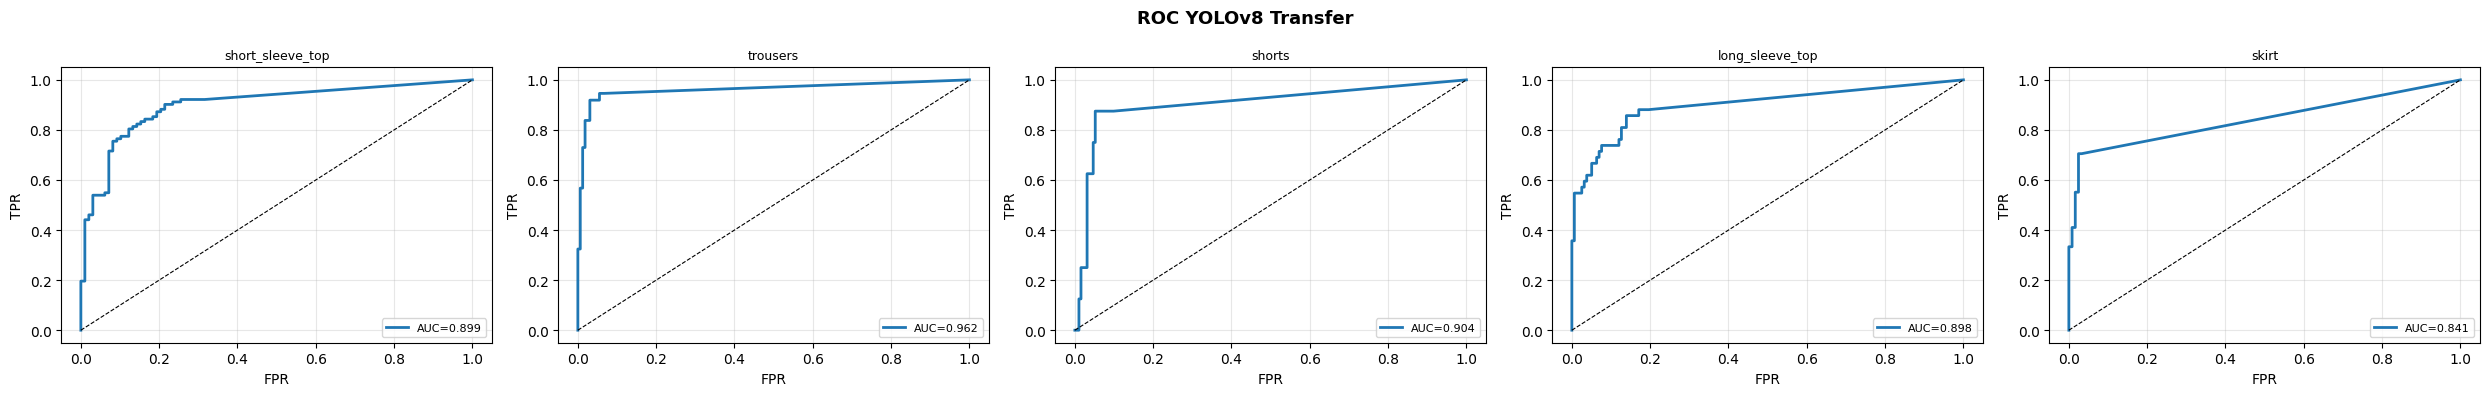

In [14]:
# ── 12. ROC Curves ────────────────────────────────────────────────────────────
def plot_roc(gt, probs, aucs, title):
    fig, axes = plt.subplots(1, len(TOP5_NAMES), figsize=(5*len(TOP5_NAMES), 4))
    for i, (name, auc, ax) in enumerate(zip(TOP5_NAMES, aucs, axes)):
        try:
            fpr, tpr, _ = roc_curve(gt[:, i], probs[:, i])
            ax.plot(fpr, tpr, lw=2, label=f'AUC={auc:.3f}')
        except: pass
        ax.plot([0,1],[0,1],'k--',lw=0.8)
        ax.set_title(name, fontsize=9)
        ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
        ax.legend(loc='lower right', fontsize=8); ax.grid(alpha=0.3)
    plt.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(OUT_DIR / f'roc_{title.replace(" ","_")}.png', dpi=150)
    plt.show()

# plot_roc(gt_s,  prob_s,  aucs_s,  'ROC YOLOv8 Scratch')
plot_roc(gt_tl, prob_tl, aucs_tl, 'ROC YOLOv8 Transfer')

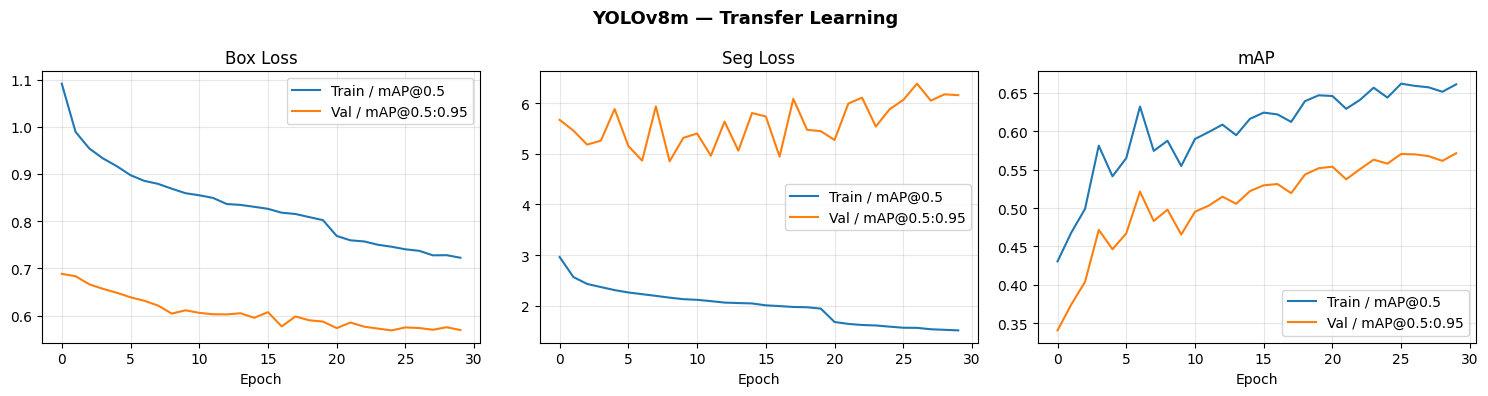

In [15]:
# ── 13. Training curves (from YOLO results.csv) ───────────────────────────────
import pandas as pd

def plot_yolo_curves(run_name, label):
    csv_path = OUT_DIR / 'runs' / run_name / 'results.csv'
    if not csv_path.exists():
        print(f'results.csv not found for {run_name}'); return
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    metrics = [
        ('train/box_loss', 'val/box_loss',   'Box Loss'),
        ('train/seg_loss', 'val/seg_loss',   'Seg Loss'),
        ('metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'mAP'),
    ]
    for ax, (c1, c2, t) in zip(axes, metrics):
        if c1 in df.columns: ax.plot(df[c1], label='Train / mAP@0.5')
        if c2 in df.columns: ax.plot(df[c2], label='Val / mAP@0.5:0.95')
        ax.set_title(t); ax.set_xlabel('Epoch'); ax.legend(); ax.grid(alpha=0.3)
    plt.suptitle(f'YOLOv8m — {label}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(OUT_DIR / f'curves_{run_name}.png', dpi=150)
    plt.show()

# plot_yolo_curves('scratch',  'Scratch')
plot_yolo_curves('transfer', 'Transfer Learning')

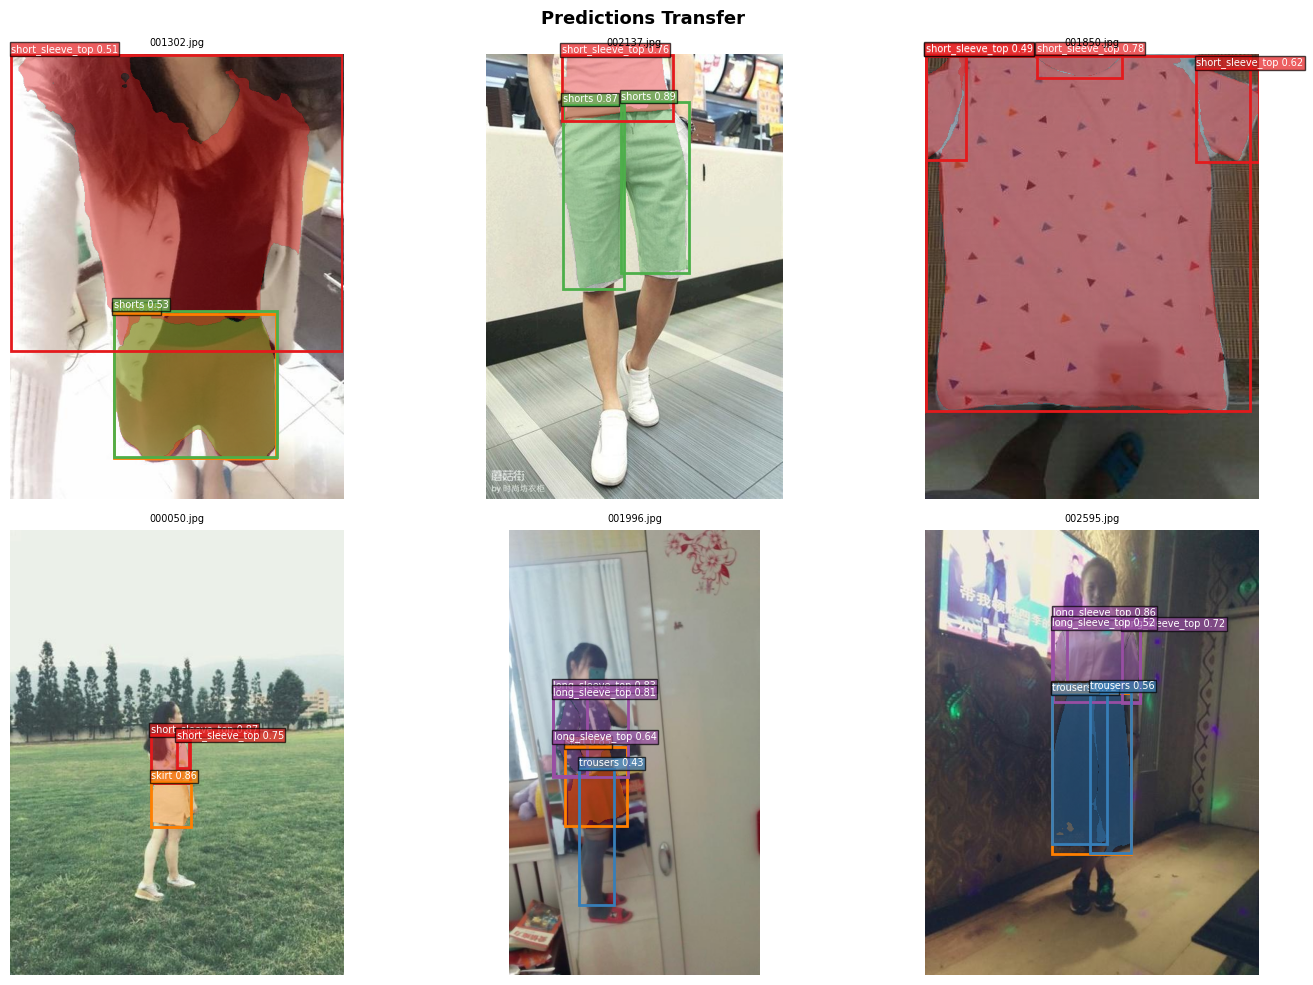

In [16]:
# ── 14. Qualitative visualisation — predictions on val images ─────────────────
COLORS_VIZ = plt.cm.Set1.colors

def visualise_predictions(model, img_dir, n=6, conf=0.3, title='Predictions'):
    img_paths = random.sample(list(img_dir.glob('*.jpg')),
                              min(n, len(list(img_dir.glob('*.jpg')))))
    cols = 3; rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols*5, rows*5))
    axes = axes.flatten()

    for ax, img_path in zip(axes, img_paths):
        results = model.predict(str(img_path), conf=conf, verbose=False)
        result  = results[0]
        img_np  = np.array(Image.open(img_path))
        H, W    = img_np.shape[:2]

        ax.imshow(img_np); ax.axis('off')

        # Draw masks & boxes
        if result.masks is not None:
            for mask_data, box, cls_id, conf_val in zip(
                    result.masks.data, result.boxes.xyxy,
                    result.boxes.cls,  result.boxes.conf):
                cls   = int(cls_id.item())
                if cls >= len(TOP5_NAMES): continue
                color = COLORS_VIZ[cls % len(COLORS_VIZ)]

                # Mask overlay
                m = mask_data.cpu().numpy()
                m = np.array(Image.fromarray((m*255).astype(np.uint8)).resize((W,H))) > 127
                overlay = np.zeros((*m.shape, 4))
                overlay[m] = (*color[:3], 0.4)
                ax.imshow(overlay)

                # Bounding box
                x1,y1,x2,y2 = box.cpu().numpy()
                rect = patches.Rectangle((x1,y1), x2-x1, y2-y1,
                                         linewidth=2, edgecolor=color, facecolor='none')
                ax.add_patch(rect)
                ax.text(x1, y1-4, f'{TOP5_NAMES[cls]} {conf_val:.2f}',
                        fontsize=7, color='white',
                        bbox=dict(facecolor=color, alpha=0.7, pad=1))
        ax.set_title(img_path.name, fontsize=7)

    for ax in axes[n:]: ax.axis('off')
    plt.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(OUT_DIR / f'qualitative_{title.replace(" ","_")}.png', dpi=150)
    plt.show()

# visualise_predictions(m_scratch, val_img_dir, n=6, title='Predictions Scratch')
visualise_predictions(m_tl,      val_img_dir, n=6, title='Predictions Transfer')

In [17]:
# ── 15. Summary results table ─────────────────────────────────────────────────
rows = []
for val_res, iou_list, dice_list, aucs, name in [
    # (val_scratch, iou_s,  dice_s,  aucs_s,  'YOLOv8m-Scratch'),
    (val_tl,      iou_tl, dice_tl, aucs_tl, 'YOLOv8m-Transfer'),
]:
    row = {'Model': name}
    row['mAP@0.5 (det)']    = round(float(val_res.box.map50), 4)
    row['mAP@0.5:0.95 (det)'] = round(float(val_res.box.map),   4)
    row['mAP@0.5 (seg)']    = round(float(val_res.seg.map50), 4)
    row['mAP@0.5:0.95 (seg)'] = round(float(val_res.seg.map),   4)
    row['mIoU (macro)']     = round(float(np.mean(iou_list)),  4)
    row['Dice (macro)']     = round(float(np.mean(dice_list)), 4)
    row['Macro AUC']        = round(float(np.nanmean(aucs)),   4)
    rows.append(row)

df = pd.DataFrame(rows).set_index('Model')
pd.set_option('display.max_columns', None)
print(df.to_string())
df.to_csv(OUT_DIR / 'results_yolov8.csv')
print('\nSaved → results_yolov8.csv')

                  mAP@0.5 (det)  mAP@0.5:0.95 (det)  mAP@0.5 (seg)  mAP@0.5:0.95 (seg)  mIoU (macro)  Dice (macro)  Macro AUC
Model                                                                                                                        
YOLOv8m-Transfer         0.6616              0.5719         0.4271              0.2706        0.4626        0.5018     0.9009

Saved → results_yolov8.csv


In [18]:
# ── 16. Save best model for Hugging Face ─────────────────────────────────────
# best_map_s  = float(val_scratch.seg.map)
best_map_tl = float(val_tl.seg.map)
best_weights = TL_WEIGHTS
best_name    = 'transfer'
print(f'Best: Transfer  (seg mAP@0.5:0.95 = {best_map_tl:.4f})')


shutil.copy(best_weights, OUT_DIR / 'yolov8m_seg_best.pt')

# Save metadata
meta = {
    'model'     : 'yolov8m-seg',
    'strategy'  : best_name,
    'top5_ids'  : TOP5_IDS,
    'top5_names': TOP5_NAMES,
    'num_classes': len(TOP5_IDS),
    'imgsz'     : 640
}
with open(OUT_DIR / 'yolov8m_seg_metadata.json', 'w') as f:
    json.dump(meta, f, indent=2)

print('\nAll output files:')
for fn in sorted(os.listdir(OUT_DIR)):
    fpath = OUT_DIR / fn
    if fpath.is_file():
        print(f'  {fn:<45} {os.path.getsize(fpath)/1e6:.1f} MB')

Best: Transfer  (seg mAP@0.5:0.95 = 0.2706)

All output files:
  __notebook__.ipynb                            20.4 MB
  curves_transfer.png                           0.1 MB
  deepfashion.yaml                              0.0 MB
  qualitative_Predictions_Transfer.png          2.1 MB
  results_yolov8.csv                            0.0 MB
  roc_ROC_YOLOv8_Transfer.png                   0.1 MB
  sample_train.png                              1.7 MB
  yolo26n.pt                                    5.5 MB
  yolov8m-seg.pt                                54.9 MB
  yolov8m_seg_best.pt                           54.8 MB
  yolov8m_seg_metadata.json                     0.0 MB


In [19]:
# ── 17. Inference script (for HuggingFace / hidden test set) ─────────────────
inference_code = '''
"""
inference.py — YOLOv8m-seg Clothing Detection & Segmentation
Usage:
    python inference.py --image path/to/image.jpg --weights yolov8m_seg_best.pt
"""
import argparse, json
import numpy as np
from ultralytics import YOLO
from PIL import Image

CLASS_NAMES = None  # loaded from metadata

def load_model(weights_path, metadata_path='yolov8m_seg_metadata.json'):
    global CLASS_NAMES
    model = YOLO(weights_path)
    with open(metadata_path) as f:
        meta = json.load(f)
    CLASS_NAMES = meta['top5_names']
    return model

def predict(model, img_path, conf=0.25, iou=0.45):
    results = model.predict(img_path, conf=conf, iou=iou, verbose=False)
    result  = results[0]
    output  = []
    if result.boxes is not None:
        for i, (box, cls, conf_val) in enumerate(
                zip(result.boxes.xyxy, result.boxes.cls, result.boxes.conf)):
            entry = {
                'class_id'  : int(cls.item()),
                'class_name': CLASS_NAMES[int(cls.item())] if CLASS_NAMES else str(int(cls.item())),
                'confidence': round(float(conf_val.item()), 4),
                'bbox_xyxy' : box.cpu().numpy().tolist(),
            }
            if result.masks is not None:
                entry['mask'] = result.masks.data[i].cpu().numpy().tolist()
            output.append(entry)
    return output

if __name__ == "__main__":
    parser = argparse.ArgumentParser()
    parser.add_argument('--image',   required=True)
    parser.add_argument('--weights', required=True)
    parser.add_argument('--conf',    type=float, default=0.25)
    args  = parser.parse_args()
    model = load_model(args.weights)
    preds = predict(model, args.image, args.conf)
    print(json.dumps(preds, indent=2))
'''

with open(OUT_DIR / 'inference.py', 'w') as f:
    f.write(inference_code)
print('inference.py written.')

inference.py written.


In [20]:
from IPython.display import FileLink
FileLink('/kaggle/working/yolov8m_seg_best.pt')

/kaggle/working/yolov8m_seg_best.pt


🚀 Running YOLO Evaluation...

Ultralytics 8.4.32 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8m-seg summary (fused): 106 layers, 27,225,279 parameters, 0 gradients, 104.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1225.7±280.6 MB/s, size: 36.4 KB)
val: Scanning /kaggle/working/deepfashion_yolo/val/labels.cache... 2002 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2002/2002 839.7Mit/s 0.0s
val: /kaggle/working/deepfashion_yolo/val/images/000643.jpg: 1 duplicate labels removed
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 126/126 2.4it/s 53.6s
                   all       2002       3060      0.656      0.558      0.662      0.572      0.441      0.402      0.427       0.27
      short_sleeve_top        877        915      0.613      0.701      0.746      0.699      0.517       0.74      0.747      0.465
              trousers        520 

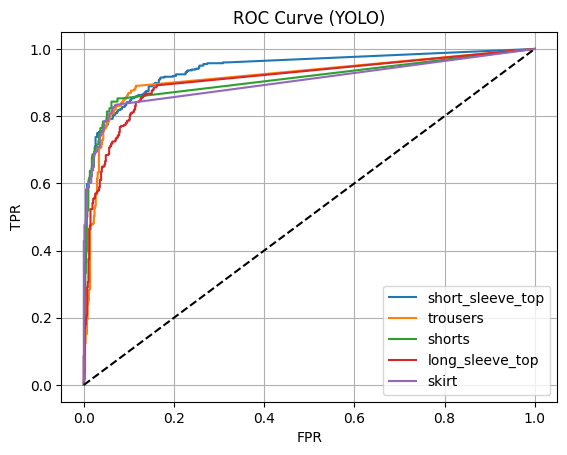

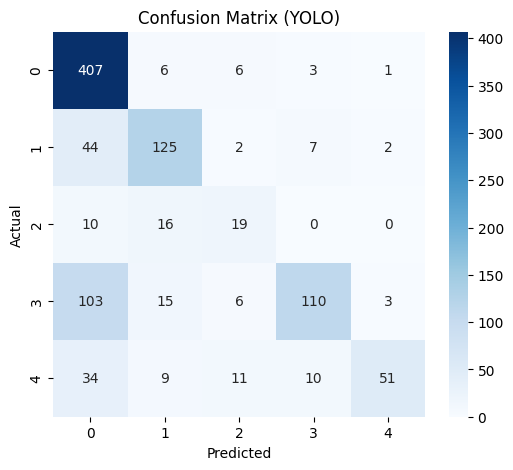


📸 Showing predictions...



array([[[ 24,  12, 138],
        [ 20,   8, 134],
        [ 15,   3, 133],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       [[ 22,  10, 136],
        [ 20,   8, 134],
        [ 17,   6, 133],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       [[ 18,   7, 131],
        [ 19,   7, 133],
        [ 20,   9, 136],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       ...,

       [[  8,  15,  12],
        [  8,  15,  12],
        [  9,  16,  13],
        ...,
        [ 27,  36,  33],
        [ 30,  39,  36],
        [ 32,  41,  38]],

       [[  9,  16,  13],
        [  9,  16,  13],
        [ 10,  17,  14],
        ...,
        [ 29,  39,  33],
        [ 30,  40,  34],
        [ 30,  40,  34]],

       [[  9,  16,  13],
        [  9,  16,  13],
        [ 10,  17,  14],
        ...,
        [ 32,  42,  36],
        [ 29,  39,  33],
        [ 27,  37,  31]]

array([[[248, 253, 252],
        [249, 254, 253],
        [250, 255, 254],
        ...,
        [183, 223,   0],
        [183, 223,   0],
        [183, 223,   0]],

       [[248, 253, 252],
        [249, 254, 253],
        [250, 255, 254],
        ...,
        [183, 223,   0],
        [183, 223,   0],
        [183, 223,   0]],

       [[249, 254, 252],
        [249, 254, 252],
        [250, 255, 253],
        ...,
        [116, 144,   4],
        [130, 161,   4],
        [183, 223,   0]],

       ...,

       [[ 29,  39,  33],
        [ 27,  37,  31],
        [ 26,  36,  30],
        ...,
        [183, 223,   0],
        [183, 223,   0],
        [183, 223,   0]],

       [[ 29,  39,  33],
        [ 27,  37,  31],
        [ 26,  36,  30],
        ...,
        [183, 223,   0],
        [183, 223,   0],
        [183, 223,   0]],

       [[ 29,  38,  35],
        [ 27,  36,  33],
        [ 26,  35,  32],
        ...,
        [183, 223,   0],
        [183, 223,   0],
        [183, 223,   0]]

array([[[133, 142, 151],
        [143, 152, 161],
        [141, 150, 159],
        ...,
        [190, 190, 202],
        [193, 193, 205],
        [195, 195, 207]],

       [[134, 143, 152],
        [145, 154, 163],
        [142, 151, 160],
        ...,
        [192, 192, 204],
        [195, 195, 207],
        [196, 196, 208]],

       [[136, 145, 154],
        [146, 155, 164],
        [143, 152, 161],
        ...,
        [191, 191, 203],
        [194, 194, 206],
        [195, 195, 207]],

       ...,

       [[101, 125, 137],
        [104, 128, 140],
        [100, 120, 131],
        ...,
        [103, 129, 143],
        [106, 132, 146],
        [108, 134, 148]],

       [[109, 133, 145],
        [105, 129, 141],
        [101, 121, 132],
        ...,
        [107, 134, 148],
        [112, 139, 153],
        [115, 142, 156]],

       [[109, 133, 145],
        [105, 129, 141],
        [101, 121, 132],
        ...,
        [107, 134, 148],
        [112, 139, 153],
        [115, 142, 156]]

array([[[106, 113, 138],
        [108, 115, 140],
        [108, 113, 138],
        ...,
        [106, 109, 140],
        [102, 105, 136],
        [ 98, 101, 132]],

       [[125, 132, 157],
        [118, 125, 150],
        [113, 118, 143],
        ...,
        [103, 106, 137],
        [102, 105, 136],
        [100, 103, 134]],

       [[128, 137, 164],
        [110, 119, 146],
        [ 98, 105, 130],
        ...,
        [107, 110, 141],
        [108, 111, 142],
        [110, 113, 144]],

       ...,

       [[ 41,  66,  98],
        [ 41,  66,  98],
        [ 41,  66,  98],
        ...,
        [ 23,  40,  67],
        [ 23,  40,  67],
        [ 23,  40,  67]],

       [[ 41,  66,  98],
        [ 41,  66,  98],
        [ 41,  66,  98],
        ...,
        [ 23,  40,  67],
        [ 23,  40,  67],
        [ 23,  40,  67]],

       [[ 41,  66,  98],
        [ 41,  66,  98],
        [ 41,  66,  98],
        ...,
        [ 23,  40,  67],
        [ 23,  40,  67],
        [ 23,  40,  67]]

array([[[ 37,  38,  76],
        [ 49,  51,  85],
        [ 76,  78, 108],
        ...,
        [183, 223,   0],
        [183, 223,   0],
        [183, 223,   0]],

       [[ 41,  42,  80],
        [ 45,  47,  82],
        [ 60,  62,  92],
        ...,
        [183, 223,   0],
        [183, 223,   0],
        [183, 223,   0]],

       [[ 41,  41,  81],
        [ 38,  40,  75],
        [ 41,  43,  73],
        ...,
        [183, 223,   0],
        [183, 223,   0],
        [183, 223,   0]],

       ...,

       [[205, 222, 211],
        [203, 220, 209],
        [204, 221, 210],
        ...,
        [175, 192, 189],
        [171, 188, 185],
        [170, 187, 184]],

       [[211, 228, 217],
        [206, 223, 212],
        [204, 221, 210],
        ...,
        [171, 188, 185],
        [167, 184, 181],
        [166, 183, 180]],

       [[205, 222, 211],
        [202, 219, 208],
        [202, 219, 208],
        ...,
        [172, 189, 186],
        [169, 186, 183],
        [167, 184, 181]]


✅ YOLO Evaluation Complete



In [21]:
# ================== YOLO FINAL EVALUATION CELL ==================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix
)

print("\n🚀 Running YOLO Evaluation...\n")

# ----------------------------
# 1. VALIDATION (mAP)
# ----------------------------
metrics = model_tl.val()
print("\n========== YOLO mAP METRICS ==========\n")
print(metrics)

# ----------------------------
# 2. COLLECT PREDICTIONS
# ----------------------------
y_true = []
y_pred = []
y_probs = []

val_images = list((YOLO_ROOT / 'val' / 'images').glob('*.jpg'))

for img_path in val_images[:1000]:  # limit for speed

    results = model_tl.predict(str(img_path), conf=0.25, verbose=False)

    pred_classes = []
    pred_scores  = []

    if len(results[0].boxes) > 0:
        for box in results[0].boxes:
            pred_classes.append(int(box.cls))
            pred_scores.append(float(box.conf))

    # multi-label vector
    gt_vec = np.zeros(len(TOP5_IDS))
    pred_vec = np.zeros(len(TOP5_IDS))
    prob_vec = np.zeros(len(TOP5_IDS))

    # --- Ground truth ---
    ann_path = YOLO_ROOT / 'val' / 'labels' / (img_path.stem + '.txt')
    if ann_path.exists():
        for line in ann_path.read_text().splitlines():
            cls = int(line.split()[0])
            gt_vec[cls] = 1

    # --- Predictions ---
    for cls, score in zip(pred_classes, pred_scores):
        pred_vec[cls] = 1
        prob_vec[cls] = max(prob_vec[cls], score)

    y_true.append(gt_vec)
    y_pred.append(pred_vec)
    y_probs.append(prob_vec)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_probs = np.array(y_probs)

# ----------------------------
# 3. METRICS
# ----------------------------
precision_macro = precision_score(y_true, y_pred, average="macro", zero_division=0)
recall_macro    = recall_score(y_true, y_pred, average="macro", zero_division=0)
f1_macro        = f1_score(y_true, y_pred, average="macro", zero_division=0)

roc_auc_macro   = roc_auc_score(y_true, y_probs, average="macro")

print("\n========== CLASSIFICATION METRICS ==========\n")
print(f"Precision (Macro): {precision_macro:.4f}")
print(f"Recall (Macro):    {recall_macro:.4f}")
print(f"F1 Score (Macro):  {f1_macro:.4f}")
print(f"ROC-AUC (Macro):   {roc_auc_macro:.4f}")

# ----------------------------
# 4. PER-CLASS METRICS
# ----------------------------
class_names = TOP5_NAMES

precision_pc = precision_score(y_true, y_pred, average=None, zero_division=0)
recall_pc    = recall_score(y_true, y_pred, average=None, zero_division=0)
f1_pc        = f1_score(y_true, y_pred, average=None, zero_division=0)
roc_pc       = roc_auc_score(y_true, y_probs, average=None)

print("\n========== PER-CLASS METRICS ==========\n")

for i, name in enumerate(class_names):
    print(f"{name}")
    print(f" Precision: {precision_pc[i]:.4f}")
    print(f" Recall:    {recall_pc[i]:.4f}")
    print(f" F1 Score:  {f1_pc[i]:.4f}")
    print(f" ROC-AUC:   {roc_pc[i]:.4f}")
    print("----------------------------------")

# ----------------------------
# 5. ROC CURVES
# ----------------------------
plt.figure()

for i, name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_true[:, i], y_probs[:, i])
    plt.plot(fpr, tpr, label=name)

plt.plot([0,1],[0,1],'k--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve (YOLO)")
plt.legend()
plt.grid()

plt.savefig("yolo_roc.png")
plt.show()

# ----------------------------
# 6. CONFUSION MATRIX
# ----------------------------
cm = confusion_matrix(y_true.argmax(axis=1), y_pred.argmax(axis=1))

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix (YOLO)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("yolo_confusion_matrix.png")
plt.show()

# ----------------------------
# 7. QUALITATIVE PREDICTIONS
# ----------------------------
print("\n📸 Showing predictions...\n")

sample_imgs = val_images[:5]

for img_path in sample_imgs:
    results = model_tl.predict(str(img_path), conf=0.3)
    display(results[0].plot())

print("\n✅ YOLO Evaluation Complete\n")